# TUs simulation safety parameter plots

In [1]:
import utils
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

planning_simulations = True

In [2]:
# Determine simulation location
if planning_simulations:
    simulations_location = 'planning'
else:
    simulations_location = 'post-hoc'

# Make output folder
plot_dir = os.path.join('..','TUS','plots','acoustic_simulations', simulations_location)
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### Find all csv's from the stimulation output folder

In [3]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/{simulations_location}/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-005/sub-005_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-005/sub-005_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-010/sub-010_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-014/sub-014_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-015/sub-015_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-016/sub-016_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-022/sub-022_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

### Save them in one dataframe
And add columns with the individual subject_id's, targets etc

In [4]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]
    
    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')
    
    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    duty_cycle = stimulation_output_filename_parts[7]                       # e.g. 'dc1'
    intensity = '_'.join(stimulation_output_filename_parts[8:10])           # e.g. 'strength_1'
    
    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    df['intensity'] = intensity
    df['duty_cycle'] = duty_cycle
    
    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0             5  36.534250                   36.534250            26.004807   
1             5  20.488410                   20.488410            26.004807   
2            10  25.218930                   25.218930            77.506451   
3            14  21.718500                   21.718500            27.825348   
4            15  23.870390                   23.870390            24.005208   
..          ...        ...                         ...                  ...   
167          28  23.827840                   23.827840            13.509256   
168          29  25.126100                   25.126100            14.008926   
169          38  27.083420                   12.764720             5.000000   
170          40   7.289176                    6.143037             7.582875   
171          44  20.156840                   20.156840            13.000000   

     max_Isppa_skin  max_Isppa_skull  max_Isppa_bra

### Reorder the dataframe and replace strings

In [5]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)

# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '60', 'strength_3': '80'})

# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

     subject_id      target intensity duty_cycle  max_Isppa  \
0             5  target_1_1        35        20%   20.48841   
1             5  target_1_1        63        20%   36.53425   
2             5  target_1_2        35        20%   19.54413   
3             5  target_1_2        63        20%   36.28726   
4             5  target_1_3        35        20%   20.48841   
..          ...         ...       ...        ...        ...   
167          44  target_2_4        81        20%   20.15684   
168          44  target_2_5        81        20%   22.04985   
169          44  target_2_6        81        20%   23.80134   
170         100  target_1_1        63        20%   29.31436   
171         100  target_1_2        63        20%   36.37210   

     max_Isppa_after_exit_plane  max_Isppa_skin  max_Isppa_skull  \
0                      20.48841        20.48841         5.735331   
1                      36.53425        36.53425         9.081082   
2                      19.54413        

# Mechanical index
1.9 is the safety limit
Group by target and intensity

In [6]:
safety_limit = 1.9

### Skin

    subject_id      target        35        63
0            5  target_1_1  1.548227  2.067429
1            5  target_1_2  1.512129  2.060429
2            5  target_1_3  1.548227  2.067429
3            5  target_1_4  1.512129  2.060429
4            5  target_1_5  1.548227  2.067429
5            5  target_1_6  1.512129  2.060429
6           10  target_1_1       NaN  1.531584
7           10  target_1_2       NaN  1.672399
8           10  target_1_3       NaN  1.531584
9           10  target_1_4       NaN  1.672399
10          10  target_1_5       NaN  1.531584
11          10  target_1_6       NaN  1.672399
12          14  target_1_1       NaN  1.594026
13          14  target_1_2       NaN  1.827072
14          14  target_1_3       NaN  1.594026
15          14  target_1_4       NaN  1.827072
16          14  target_1_5       NaN  1.594026
17          14  target_1_6       NaN  1.827072
18          15  target_1_1       NaN  1.671130
19          15  target_1_2       NaN  2.161564
20          1

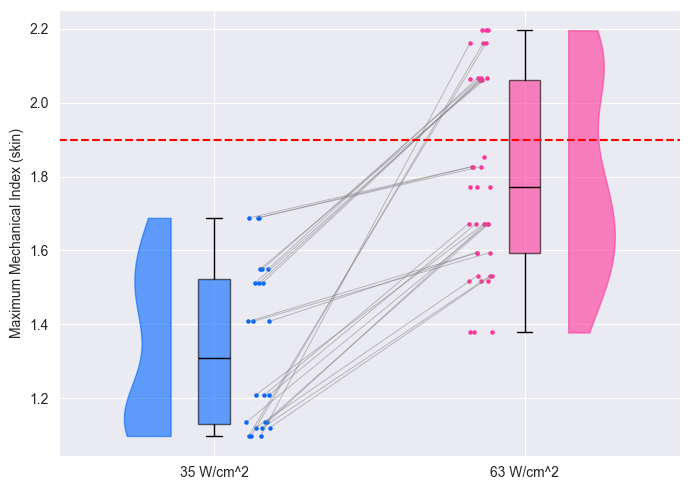

In [7]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='60',
        labels=['35 W/cm^2', '40 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (skin)',
        plot_name='Maximum MI in skin for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [8]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='60',
        column_2='80',
        labels=['60 W/cm^2', '80 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (skin)',
        plot_name='Maximum MI in skin for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  1.496021
1            5  target_2_2 NaN  1.428994
2            5  target_2_3 NaN  1.413054
3            5  target_2_4 NaN  1.407157
4            5  target_2_5 NaN  1.555427
..         ...         ...  ..       ...
87          44  target_2_2 NaN  1.672146
88          44  target_2_3 NaN  1.575711
89          44  target_2_4 NaN  1.535648
90          44  target_2_5 NaN  1.606140
91          44  target_2_6 NaN  1.668711

[92 rows x 4 columns]
Skipping block due to error: '63'


### Brain

    subject_id      target        35        63
0            5  target_1_1  0.869300  1.155558
1            5  target_1_2  0.873732  1.166443
2            5  target_1_3  0.869300  1.155558
3            5  target_1_4  0.873732  1.166443
4            5  target_1_5  0.869300  1.155558
5            5  target_1_6  0.873732  1.166443
6           10  target_1_1       NaN  1.230412
7           10  target_1_2       NaN  1.108159
8           10  target_1_3       NaN  1.230412
9           10  target_1_4       NaN  1.108159
10          10  target_1_5       NaN  1.230412
11          10  target_1_6       NaN  1.108159
12          14  target_1_1       NaN  1.190208
13          14  target_1_2       NaN  1.083744
14          14  target_1_3       NaN  1.190208
15          14  target_1_4       NaN  1.083744
16          14  target_1_5       NaN  1.190208
17          14  target_1_6       NaN  1.083744
18          15  target_1_1       NaN  1.176521
19          15  target_1_2       NaN  0.959089
20          1

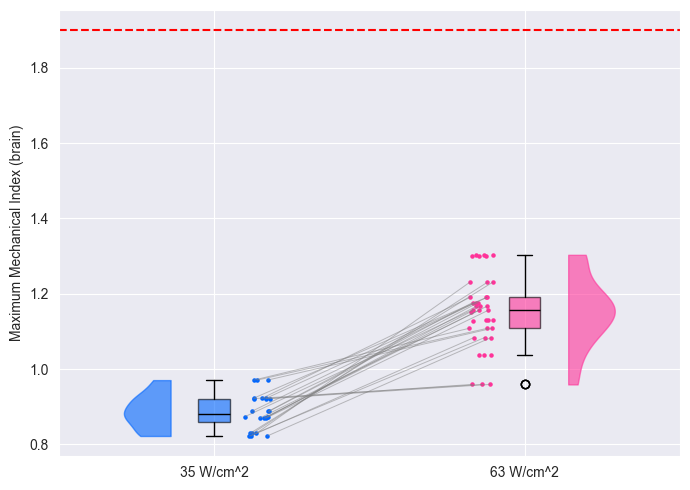

In [9]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='60',
        labels=['35 W/cm^2', '40 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (brain)',
        plot_name='Maximum MI in brain for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [10]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='60',
        column_2='80',
        labels=['60 W/cm^2', '80 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (brain)',
        plot_name='Maximum MI in brain for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  0.828914
1            5  target_2_2 NaN  0.905166
2            5  target_2_3 NaN  0.763167
3            5  target_2_4 NaN  0.859165
4            5  target_2_5 NaN  0.825211
..         ...         ...  ..       ...
87          44  target_2_2 NaN  0.867562
88          44  target_2_3 NaN  0.703633
89          44  target_2_4 NaN  0.851232
90          44  target_2_5 NaN  0.699298
91          44  target_2_6 NaN  0.808866

[92 rows x 4 columns]
Skipping block due to error: '63'


# CEM43
0.25 is the safety limit
Group by target and intensity

In [11]:
safety_limit = 0.25

## Skin

    subject_id      target        35        63
0            5  target_1_1  0.000000  0.000000
1            5  target_1_2  0.000046  0.000046
2            5  target_1_3  0.000075  0.000075
3            5  target_1_4       NaN  0.000135
4            5  target_1_5       NaN  0.000165
5            5  target_1_6       NaN  0.000383
6           10  target_1_1       NaN  0.000000
7           10  target_1_2       NaN  0.000060
8           10  target_1_3       NaN  0.000075
9           14  target_1_1       NaN  0.000000
10          14  target_1_2       NaN  0.000050
11          14  target_1_3       NaN  0.000076
12          15  target_1_1       NaN  0.000000
13          15  target_1_2       NaN  0.000074
14          15  target_1_3       NaN  0.000078
15          16  target_1_1  0.000000       NaN
16          16  target_1_2  0.000076       NaN
17          16  target_1_3  0.000078       NaN
18          22  target_1_1  0.000000  0.000000
19          22  target_1_2  0.000076  0.000074
20          2

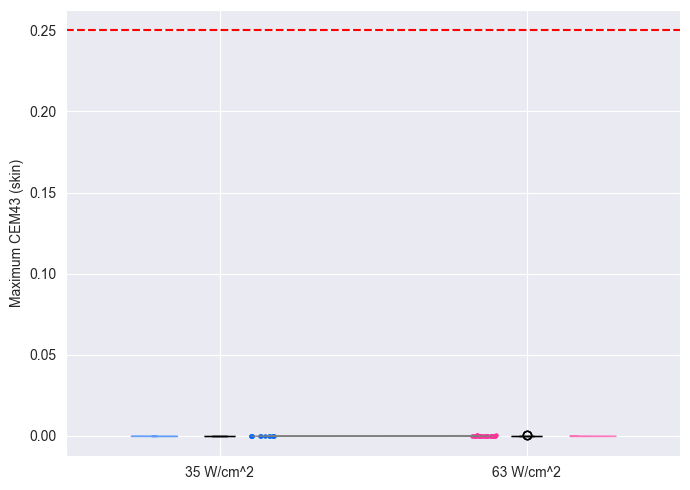

In [12]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='60',
        labels=['35 W/cm^2', '40 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (skin)',
        plot_name='Maximum CEM43 in skin for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [13]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='60',
        column_2='80',
        labels=['60 W/cm^2', '80 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (skin)',
        plot_name='Maximum CEM43 in skin for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  0.000000
1            5  target_2_2 NaN  0.000084
2            5  target_2_3 NaN  0.000112
3            5  target_2_4 NaN  0.000187
4            5  target_2_5 NaN  0.000213
..         ...         ...  ..       ...
84          44  target_2_2 NaN  0.000088
85          44  target_2_3 NaN  0.000095
86          44  target_2_4 NaN  0.000197
87          44  target_2_5 NaN  0.000227
88          44  target_2_6 NaN  0.000433

[89 rows x 4 columns]
Skipping block due to error: '63'


## Brain

    subject_id      target        35        63
0            5  target_1_1  0.000035  0.000037
1            5  target_1_2  0.000081  0.000084
2            5  target_1_3  0.000128  0.000132
3            5  target_1_4       NaN  0.000190
4            5  target_1_5       NaN  0.000257
5            5  target_1_6       NaN  0.000476
6           10  target_1_1       NaN  0.000037
7           10  target_1_2       NaN  0.000086
8           10  target_1_3       NaN  0.000132
9           14  target_1_1       NaN  0.000037
10          14  target_1_2       NaN  0.000082
11          14  target_1_3       NaN  0.000132
12          15  target_1_1       NaN  0.000037
13          15  target_1_2       NaN  0.000078
14          15  target_1_3       NaN  0.000127
15          16  target_1_1  0.000035       NaN
16          16  target_1_2  0.000080       NaN
17          16  target_1_3  0.000127       NaN
18          22  target_1_1  0.000035  0.000036
19          22  target_1_2  0.000081  0.000083
20          2

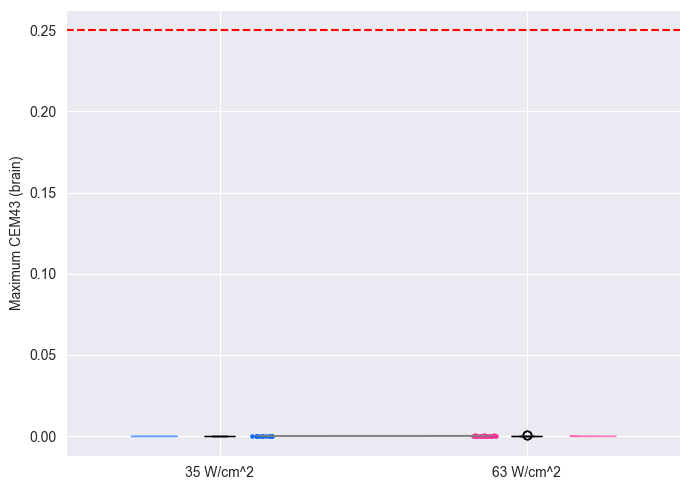

In [14]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='60',
        labels=['35 W/cm^2', '40 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (brain)',
        plot_name='Maximum CEM43 in brain for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [15]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='60',
        column_2='80',
        labels=['60 W/cm^2', '80 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (brain)',
        plot_name='Maximum CEM43 in brain for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  0.000042
1            5  target_2_2 NaN  0.000093
2            5  target_2_3 NaN  0.000145
3            5  target_2_4 NaN  0.000200
4            5  target_2_5 NaN  0.000269
..         ...         ...  ..       ...
84          44  target_2_2 NaN  0.000095
85          44  target_2_3 NaN  0.000147
86          44  target_2_4 NaN  0.000206
87          44  target_2_5 NaN  0.000280
88          44  target_2_6 NaN  0.000461

[89 rows x 4 columns]
Skipping block due to error: '63'


# Max temperature rise in skin and brain
2 degrees is the safety limit
Group by target and intensity

In [16]:
safety_limit = 39

## Skin

    subject_id      target        35        63
0            5  target_1_1  36.92072  36.92179
1            5  target_1_2  38.36076  38.29488
2            5  target_1_3  38.28225  38.28082
3            5  target_1_4       NaN  38.28617
4            5  target_1_5       NaN  38.28264
5            5  target_1_6       NaN  38.62675
6           10  target_1_1       NaN  36.90647
7           10  target_1_2       NaN  38.29335
8           10  target_1_3       NaN  38.30488
9           14  target_1_1       NaN  36.98271
10          14  target_1_2       NaN  38.13757
11          14  target_1_3       NaN  38.34142
12          15  target_1_1       NaN  36.90236
13          15  target_1_2       NaN  38.34617
14          15  target_1_3       NaN  38.13461
15          16  target_1_1  36.92390       NaN
16          16  target_1_2  37.39572       NaN
17          16  target_1_3  37.40537       NaN
18          22  target_1_1  36.89604  36.89609
19          22  target_1_2  38.28635  38.28725
20          2

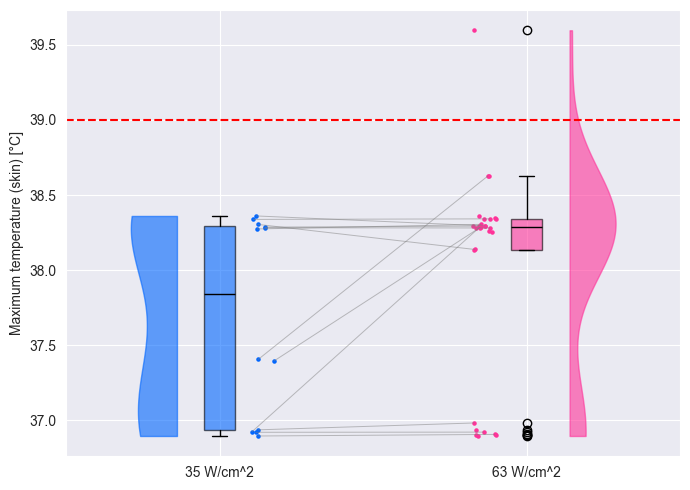

In [17]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='60',
        labels=['35 W/cm^2', '40 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (skin) [°C]',
        plot_name='Maximum temp in skin for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [18]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='60',
        column_2='80',
        labels=['60 W/cm^2', '80 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (skin) [°C]',
        plot_name='Maximum temp in skin for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35         81
0            5  target_2_1 NaN  36.896435
1            5  target_2_2 NaN  38.431705
2            5  target_2_3 NaN  38.418870
3            5  target_2_4 NaN  38.421025
4            5  target_2_5 NaN  38.406590
..         ...         ...  ..        ...
84          44  target_2_2 NaN  38.785870
85          44  target_2_3 NaN  38.552950
86          44  target_2_4 NaN  38.588120
87          44  target_2_5 NaN  38.443840
88          44  target_2_6 NaN  38.344360

[89 rows x 4 columns]
Skipping block due to error: '63'


## Brain

    subject_id      target        35        63
0            5  target_1_1  37.06095  37.10559
1            5  target_1_2  37.93092  37.92762
2            5  target_1_3  37.94563  37.94963
3            5  target_1_4       NaN  37.92797
4            5  target_1_5       NaN  37.96288
5            5  target_1_6       NaN  38.24635
6           10  target_1_1       NaN  37.11329
7           10  target_1_2       NaN  37.93334
8           10  target_1_3       NaN  37.85046
9           14  target_1_1       NaN  37.11457
10          14  target_1_2       NaN  37.95130
11          14  target_1_3       NaN  37.86281
12          15  target_1_1       NaN  37.11430
13          15  target_1_2       NaN  37.74899
14          15  target_1_3       NaN  37.65352
15          16  target_1_1  37.05363       NaN
16          16  target_1_2  37.23071       NaN
17          16  target_1_3  37.36994       NaN
18          22  target_1_1  37.06627  37.09704
19          22  target_1_2  37.85942  37.94552
20          2

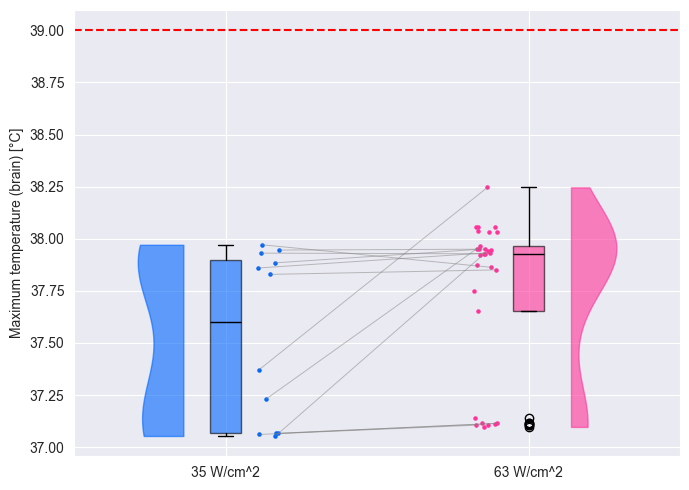

In [19]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='60',
        labels=['35 W/cm^2', '40 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (brain) [°C]',
        plot_name='Maximum temp in brain for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [20]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='60',
        column_2='80',
        labels=['60 W/cm^2', '80 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (brain) [°C]',
        plot_name='Maximum temp in brain for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35         81
0            5  target_2_1 NaN  37.054625
1            5  target_2_2 NaN  38.618430
2            5  target_2_3 NaN  38.129815
3            5  target_2_4 NaN  38.758710
4            5  target_2_5 NaN  38.068910
..         ...         ...  ..        ...
84          44  target_2_2 NaN  38.594220
85          44  target_2_3 NaN  38.007040
86          44  target_2_4 NaN  38.855900
87          44  target_2_5 NaN  38.166900
88          44  target_2_6 NaN  38.787590

[89 rows x 4 columns]
Skipping block due to error: '63'
